# LLM JUDGE TEST

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#enable pandas tdqm
from tqdm import tqdm
tqdm.pandas()

In [2]:
#load answers text cache
answers_text_cache_path = "./data/r2_cleaned.csv"
df_answers = pd.read_csv(answers_text_cache_path, keep_default_na=False) #keep_default_na=False to avoid converting empty strings to NaN
df_answers = df_answers[df_answers["REPETITION"] == 1].reset_index(drop=True)
# drop block 2
df_answers = df_answers[df_answers["BLOCK"] != 2].reset_index(drop=True)
df_answers["VIDEO_SECTOR"] = df_answers["VIDEO"].apply(lambda x: "LIMA" if int(x.split("_")[1]) <= 100 else "NYC")
print(f"Loaded answers text cache with {len(df_answers)} entries")
df_answers.head()

Loaded answers text cache with 8100 entries


,AGENT,VIDEO,BLOCK,QUESTION_NUM,REPETITION,ANSWER,VIDEO_SECTOR
0,human_lima_1,Robusto2_153,1,1,1,The ego vehicle is accelerating slowly because...,NYC
1,human_lima_2,Robusto2_153,1,1,1,The ego vehicle is turning to the right,NYC
2,human_lima_3,Robusto2_153,1,1,1,the ego vehicle brakes and steers slightly to ...,NYC
3,human_lima_4,Robusto2_153,1,1,1,Braking to yield,NYC
4,human_lima_5,Robusto2_153,1,1,1,The ego vehicle is moving forward while mainta...,NYC


In [3]:
KEYS = ["VIDEO", "QUESTION_NUM","VIDEO_SECTOR", "BLOCK", "AGENT","ANSWER"]
df_comp = pd.merge(df_answers[KEYS], df_answers[KEYS], on=["VIDEO", "QUESTION_NUM","VIDEO_SECTOR","BLOCK"], suffixes=('_I', '_J')) 
df_comp

,VIDEO,QUESTION_NUM,VIDEO_SECTOR,BLOCK,AGENT_I,ANSWER_I,AGENT_J,ANSWER_J
0,Robusto2_153,1,NYC,1,human_lima_1,The ego vehicle is accelerating slowly because...,human_lima_1,The ego vehicle is accelerating slowly because...
1,Robusto2_153,1,NYC,1,human_lima_1,The ego vehicle is accelerating slowly because...,human_lima_2,The ego vehicle is turning to the right
2,Robusto2_153,1,NYC,1,human_lima_1,The ego vehicle is accelerating slowly because...,human_lima_3,the ego vehicle brakes and steers slightly to ...
3,Robusto2_153,1,NYC,1,human_lima_1,The ego vehicle is accelerating slowly because...,human_lima_4,Braking to yield
4,Robusto2_153,1,NYC,1,human_lima_1,The ego vehicle is accelerating slowly because...,human_lima_5,The ego vehicle is moving forward while mainta...
...,...,...,...,...,...,...,...,...
218695,Robusto2_195,20,NYC,4,VideoLLaMA3-7B,The video does not provide any clear evidence ...,MiniCPM-o-2_6,"I'm sorry, but I cannot provide an analysis of..."
218696,Robusto2_195,20,NYC,4,VideoLLaMA3-7B,The video does not provide any clear evidence ...,Perception-LM-8B,"No, there is no vehicle or pedestrian in the s..."
218697,Robusto2_195,20,NYC,4,VideoLLaMA3-7B,The video does not provide any clear evidence ...,Phi-4-multimodal-instruct,"No, there are no visible signs of any vehicles..."
218698,Robusto2_195,20,NYC,4,VideoLLaMA3-7B,The video does not provide any clear evidence ...,Qwen3-VL-8B-Instruct,No vehicle or pedestrian is visibly violating ...


## JUDGER

In [4]:
JUDGE_TEMPLATE = """
You are an expert logical analyst.

Task:
Determine if Response A and Response B provide claims that can be compared for agreement or contradiction regarding the [Question].

Rules:
- Mark as 1 (COMPARABLE) if:
    1. Both responses provide a factual answer to the [Question].
    2. They describe the same object's state (e.g., if the question asks "What is the car doing?", any description of its motion—turning, stopping, or going straight—is COMPARABLE because these are competing descriptions of the same event).
    3. The responses are "on the same page" even if they disagree (e.g., "Yes" vs "No").

- Mark as 0 (NOT_COMPARABLE) if:
    1. The responses "talk past each other" (e.g., Question: "What is the car doing?"; A: "It's turning"; B: "It's a blue car"). One describes an action, the other describes an appearance. These are NOT comparable.
    2. One response provides facts while the other says "I don't know," "I can't see," or is empty.
    3. They discuss different objects entirely.

[Few-Shot Examples]
Question: "What is the ego vehicle's action?"
A: "Turning right." | B: "Moving forward." -> 1 (Comparable: These are two different descriptions of the vehicle's trajectory. If one is true, the other is likely false.)
A: "Braking." | B: "Stopped." -> 1 (Comparable: These both describe the vehicle's speed/state.)
A: "Accelerating." | B: "The car is black." -> 0 (Not Comparable: A describes motion, B describes color. They do not overlap or conflict.)

Question: "Is there a traffic light?"
A: "Yes, it is green." | B: "No." -> 1 (Comparable: One confirms existence, the other denies it.)

Output ONLY valid JSON:
{
  "Evaluation": "Briefly explain your reasoning.",
  "Score": 1 | 0
}
"""

USER_TEMPLATE = """
Input:
[Question]: {question}
[Response A]: {res_a}
[Response B]: {res_b}
"""

import os
from pathlib import Path

import yaml
from openai import AsyncOpenAI

VLLM_BASE_URL = os.getenv("VLLM_BASE_URL", "http://localhost:8000/v1")
VLLM_API_KEY = os.getenv("VLLM_API_KEY", "EMPTY")
JUDGE_MODEL = os.getenv("VLLM_MODEL", "Qwen/Qwen3-4B")

QUESTIONS_YAML_CANDIDATES = [
    Path("../../data/final_questions_v3.yaml"),
    Path("data/final_questions_v3.yaml"),
    Path("/home/adrianjcz/Desktop/Artificio/vqa_analysis/data/final_questions_v3.yaml"),
]

QUESTIONS_DB = {}
for candidate in QUESTIONS_YAML_CANDIDATES:
    if candidate.exists():
        with candidate.open("r", encoding="utf-8") as f:
            QUESTIONS_DB = yaml.safe_load(f) or {}
        print(f"Loaded questions YAML from: {candidate}")
        break

if not QUESTIONS_DB:
    raise FileNotFoundError(
        "Could not find final_questions_v3.yaml in expected paths."
    )

aclient = AsyncOpenAI(
    base_url=VLLM_BASE_URL,
    api_key=VLLM_API_KEY,
 )

def _normalize_message_field(value):
    if value is None:
        return ""
    if isinstance(value, list):
        return "".join(
            part.get("text", "") if isinstance(part, dict) else str(part)
            for part in value
        ).strip()
    return str(value).strip()

def _get_question_text(row):
    video_key = str(row.get("VIDEO", "")).strip()
    q_num_raw = row.get("QUESTION_NUM", "")
    try:
        q_key = f"Q{int(q_num_raw)}"
    except (TypeError, ValueError):
        q_key = f"Q{str(q_num_raw).strip()}"

    return (
        QUESTIONS_DB.get(video_key, {})
        .get(q_key, {})
        .get("question", "")
        .strip()
    )

# Get score using the model
async def judge_row_answers_async(row):
    question_text = _get_question_text(row)
    prompt = USER_TEMPLATE.format(
        question=question_text,
        res_a=row['ANSWER_I'],
        res_b=row['ANSWER_J']
    )
    
    completion = await aclient.chat.completions.create(
        model=JUDGE_MODEL,
        messages=[
            {"role": "system", "content": JUDGE_TEMPLATE},
            {"role": "user", "content": prompt}
        ],
        temperature=1,
        top_p=0.95,
        presence_penalty=1.5,
        extra_body={
            "top_k": 20, 
            "chat_template_kwargs": {"enable_thinking": True},
        },
    )

    msg = completion.choices[0].message
    content = _normalize_message_field(msg.content)
    reasoning_content = _normalize_message_field(
        getattr(msg, "reasoning_content", None) or getattr(msg, "reasoning", None)
    )

    return {
        "raw_output": content,
        "reasoning_content": reasoning_content,
    }
 
def judge_row_answers(row):
    raise RuntimeError("Use `await judge_row_answers_async(row)` in this notebook.")

Loaded questions YAML from: data/final_questions_v3.yaml


In [5]:
# TEMP
random_n = np.random.randint(1,218701)
print("Number:", random_n)
testy = df_comp.iloc[random_n]
print(JUDGE_TEMPLATE)
print(USER_TEMPLATE.format(
    question=_get_question_text(testy),
    res_a=testy['ANSWER_I'],
    res_b=testy['ANSWER_J']
))

Number: 26546

You are an expert logical analyst.

Task:
Determine if Response A and Response B provide claims that can be compared for agreement or contradiction regarding the [Question].

Rules:
- Mark as 1 (COMPARABLE) if:
    1. Both responses provide a factual answer to the [Question].
    2. They describe the same object's state (e.g., if the question asks "What is the car doing?", any description of its motion—turning, stopping, or going straight—is COMPARABLE because these are competing descriptions of the same event).
    3. The responses are "on the same page" even if they disagree (e.g., "Yes" vs "No").

- Mark as 0 (NOT_COMPARABLE) if:
    1. The responses "talk past each other" (e.g., Question: "What is the car doing?"; A: "It's turning"; B: "It's a blue car"). One describes an action, the other describes an appearance. These are NOT comparable.
    2. One response provides facts while the other says "I don't know," "I can't see," or is empty.
    3. They discuss different

In [6]:
import json
import re

def _extract_json_dict(text):
    text = text.strip()

    # Remove fenced code block wrappers if present
    if text.startswith("```"):
        text = re.sub(r"^```(?:json)?", "", text.strip(), flags=re.IGNORECASE).strip()
        text = re.sub(r"```$", "", text.strip()).strip()

    # First try direct parse
    try:
        return json.loads(text)
    except Exception:
        pass

    # Fallback: parse first JSON object found in the text
    match = re.search(r"\{[\s\S]*\}", text)
    if not match:
        raise ValueError("No JSON object found in model output")
    return json.loads(match.group(0))

# test on a single row
row = df_comp.iloc[random_n]
result_payload = await judge_row_answers_async(row)
print(f"Raw output:\n{result_payload['raw_output']}\n")
print(f"Reasoning content:\n{result_payload['reasoning_content']}\n")
print("JSON:")
print(json.dumps(_extract_json_dict(result_payload["raw_output"]), indent=2))

Raw output:
{
  "Evaluation": "Both responses provide numerical answers to the question about probability, though they differ in format (percentage vs. decimal) and include additional context in Response B. They address the same object (crash probability) and are factual, making them comparable despite disagreement.",
  "Score": 1
}

Reasoning content:
Okay, let's tackle this. The question is asking for the probability of a crash occurring immediately after the last frame of a clip, to two decimal places. 

Response A gives 1.60%, which is a percentage rounded to two decimal places. That directly answers the probability part of the question.

Response B says 0.18 and mentions a moderate crash risk due to poor coordination and unsafe turning. The number 0.18 is two decimal places, but it's a decimal rather than a percentage. However, converting 0.18 to a percentage would be 18.00%, which doesn't match Response A's 1.60%. But wait, the question specifies "probability," so maybe 0.18 is a

In [18]:
df_comp = df_comp[:512]

In [8]:
import asyncio
import json
import os
import re

def _extract_json_dict(text):
    text = text.strip()

    # Remove fenced code block wrappers if present
    if text.startswith("```"):
        text = re.sub(r"^```(?:json)?", "", text.strip(), flags=re.IGNORECASE).strip()
        text = re.sub(r"```$", "", text.strip()).strip()

    # First try direct parse
    try:
        return json.loads(text)
    except Exception:
        pass

    # Fallback: parse first JSON object found in the text
    match = re.search(r"\{[\s\S]*\}", text)
    if not match:
        raise ValueError("No JSON object found in model output")
    return json.loads(match.group(0))

def _resume_key_columns(df):
    # Columns that identify a pair robustly across runs/datasets
    preferred = [
        "VIDEO", "QUESTION_NUM", "VIDEO_SECTOR", "BLOCK",
        "AGENT_I", "AGENT_J", "ANSWER_I", "ANSWER_J",
    ]
    return [c for c in preferred if c in df.columns]

def _is_missing_text(series):
    s = series.astype("string")
    return s.isna() | (s.str.strip() == "")

def _is_missing_text_value(value):
    return pd.isna(value) or str(value).strip() == ""

def _json_get_ci(obj, *keys, default=None):
    if not isinstance(obj, dict):
        return default
    lower_map = {str(k).strip().lower(): v for k, v in obj.items()}
    for key in keys:
        val = lower_map.get(str(key).strip().lower(), None)
        if val is not None:
            return val
    return default

def _load_checkpoint_if_available(df, checkpoint_path):
    score_cols = ["SCORE", "EVALUATION", "REASONING_CONTENT", "RAW_OUTPUT"]

    # Ensure canonical uppercase columns exist
    if "SCORE" not in df.columns:
        df["SCORE"] = np.nan
    if "EVALUATION" not in df.columns:
        df["EVALUATION"] = pd.NA
    if "REASONING_CONTENT" not in df.columns:
        df["REASONING_CONTENT"] = pd.NA
    if "RAW_OUTPUT" not in df.columns:
        df["RAW_OUTPUT"] = pd.NA

    # Backward compatibility with old lowercase text columns
    if "evaluation" in df.columns:
        mask = _is_missing_text(df["EVALUATION"])
        df.loc[mask, "EVALUATION"] = df.loc[mask, "evaluation"]
    if "reasoning_content" in df.columns:
        mask = _is_missing_text(df["REASONING_CONTENT"])
        df.loc[mask, "REASONING_CONTENT"] = df.loc[mask, "reasoning_content"]

    if not os.path.exists(checkpoint_path):
        print(f"[checkpoint] No checkpoint found at: {checkpoint_path}")
        print("[checkpoint] Starting inference from scratch.")
        return df

    print(f"[checkpoint] Found checkpoint: {checkpoint_path}")
    ckpt_df = pd.read_parquet(checkpoint_path)
    print(f"[checkpoint] Checkpoint rows: {len(ckpt_df)} | Current pairs: {len(df)}")

    # Backward compatibility for checkpoint schema
    if "EVALUATION" not in ckpt_df.columns and "evaluation" in ckpt_df.columns:
        ckpt_df["EVALUATION"] = ckpt_df["evaluation"]
    if "REASONING_CONTENT" not in ckpt_df.columns and "reasoning_content" in ckpt_df.columns:
        ckpt_df["REASONING_CONTENT"] = ckpt_df["reasoning_content"]

    key_cols = _resume_key_columns(df)
    ckpt_key_cols = [c for c in key_cols if c in ckpt_df.columns]

    # Preferred path: migrate by key-matching (works even when row counts changed)
    if ckpt_key_cols:
        if len(ckpt_df) != len(df):
            print("[checkpoint] Row count mismatch detected.")
            print("[checkpoint] Auto-migrate mode enabled (key-based restore).")

        cols_to_take = ckpt_key_cols + [c for c in score_cols if c in ckpt_df.columns]
        ckpt_map = ckpt_df[cols_to_take].copy()
        ckpt_map = ckpt_map.drop_duplicates(subset=ckpt_key_cols, keep="last")

        before = int(df["SCORE"].notna().sum())
        merged_scores = df[ckpt_key_cols].merge(ckpt_map, on=ckpt_key_cols, how="left")

        for col in score_cols:
            if col in merged_scores.columns:
                if col == "SCORE":
                    mask = df[col].isna()
                else:
                    mask = _is_missing_text(df[col])
                incoming_ok = merged_scores[col].notna()
                df.loc[mask & incoming_ok, col] = merged_scores.loc[mask & incoming_ok, col]

        after = int(df["SCORE"].notna().sum())
        restored = after - before
        missing = len(df) - after
        print(f"[checkpoint] Restored inferred pairs: {restored}")
        print(f"[checkpoint] Remaining pairs to infer: {missing}")
        return df

    # Fallback for legacy checkpoints without key columns
    if len(ckpt_df) == len(df):
        print("[checkpoint] Key columns not available in checkpoint. Falling back to positional restore.")
        for col in score_cols:
            if col in ckpt_df.columns:
                if col == "SCORE":
                    mask = df[col].isna()
                else:
                    mask = _is_missing_text(df[col])
                incoming = ckpt_df[col]
                incoming_ok = incoming.notna()
                df.loc[mask & incoming_ok, col] = incoming.loc[mask & incoming_ok]
        already_inferred = int(df["SCORE"].notna().sum())
        missing = len(df) - already_inferred
        print(f"[checkpoint] Restored inferred pairs: {already_inferred}")
        print(f"[checkpoint] Remaining pairs to infer: {missing}")
        return df

    print("[checkpoint] Row count mismatch and no shared key columns available.")
    print("[checkpoint] Starting inference from scratch to avoid bad alignment.")
    return df

async def comparation_func_async(row, sem):
    async with sem:
        try:
            result_payload = await judge_row_answers_async(row)
            raw_output = str(result_payload.get("raw_output", "") or "").strip()

            result = {}
            if raw_output:
                try:
                    result = _extract_json_dict(raw_output)
                except Exception:
                    result = {}

            agreement_score = _json_get_ci(result, "Score", default=np.nan)
            evaluation = _json_get_ci(result, "Evaluation", "Reasoning", default="")
            reasoning_content = result_payload.get("reasoning_content", "")

            if _is_missing_text_value(reasoning_content):
                reasoning_content = _json_get_ci(result, "reasoning_content", "reasoning", "thinking", default="")

            if agreement_score is None:
                agreement_score = np.nan
            if evaluation is None:
                evaluation = ""
            if reasoning_content is None:
                reasoning_content = ""

            evaluation = str(evaluation).strip()
            reasoning_content = str(reasoning_content).strip()
            ok = True

        except Exception:
            agreement_score = np.nan
            evaluation = ""
            reasoning_content = ""
            raw_output = ""
            ok = False

    return agreement_score, evaluation, reasoning_content, raw_output, ok

async def score_dataframe_async(
    df,
    checkpoint_path,
    concurrency=32,
    batch_size=256,
    checkpoint_every_batches=10,
):
    sem = asyncio.Semaphore(concurrency)

    # Resume support
    df = _load_checkpoint_if_available(df, checkpoint_path)

    score_missing = df["SCORE"].isna()
    eval_missing = _is_missing_text(df["EVALUATION"])
    reasoning_missing = _is_missing_text(df["REASONING_CONTENT"])
    raw_missing = _is_missing_text(df["RAW_OUTPUT"])

    pending_mask = score_missing | eval_missing | reasoning_missing | raw_missing
    pending_idxs = df.index[pending_mask].tolist()

    total_pairs = len(df)
    print(f"[inference] Total pairs: {total_pairs}")
    print(f"[inference] Pairs with missing SCORE: {int(score_missing.sum())}")
    print(f"[inference] Pairs with missing EVALUATION: {int(eval_missing.sum())}")
    print(f"[inference] Pairs with missing REASONING_CONTENT: {int(reasoning_missing.sum())}")
    print(f"[inference] Pairs with missing RAW_OUTPUT: {int(raw_missing.sum())}")
    print(f"[inference] Pairs pending (any missing field): {len(pending_idxs)}")

    if not pending_idxs:
        print("[inference] Nothing to do. All pairs already have all fields.")
        return df

    for batch_i, start in enumerate(tqdm(range(0, len(pending_idxs), batch_size), desc="Scoring batches"), start=1):
        batch_idxs = pending_idxs[start:start + batch_size]
        rows = [df.loc[i] for i in batch_idxs]

        tasks = [comparation_func_async(row, sem) for row in rows]
        results = await asyncio.gather(*tasks)

        for i, (score, evaluation, reasoning_content, raw_output, ok) in zip(batch_idxs, results):
            if not ok:
                continue

            # Full-row overwrite from one inference response to keep fields coherent
            df.at[i, "SCORE"] = score
            df.at[i, "EVALUATION"] = evaluation
            df.at[i, "REASONING_CONTENT"] = reasoning_content
            df.at[i, "RAW_OUTPUT"] = raw_output

        if batch_i % checkpoint_every_batches == 0:
            df.to_parquet(checkpoint_path)
            done_score = int(df["SCORE"].notna().sum())
            done_eval = int((~_is_missing_text(df["EVALUATION"])).sum())
            done_reason = int((~_is_missing_text(df["REASONING_CONTENT"])).sum())
            done_raw = int((~_is_missing_text(df["RAW_OUTPUT"])).sum())
            print(
                f"[checkpoint] Saved after batch {batch_i}. "
                f"SCORE: {done_score}/{total_pairs} | "
                f"EVALUATION: {done_eval}/{total_pairs} | "
                f"REASONING_CONTENT: {done_reason}/{total_pairs} | "
                f"RAW_OUTPUT: {done_raw}/{total_pairs}"
            )

    df.to_parquet(checkpoint_path)
    print(f"[checkpoint] Final save complete: {checkpoint_path}")

    # Final completeness check
    done_score = int(df["SCORE"].notna().sum())
    done_eval = int((~_is_missing_text(df["EVALUATION"])).sum())
    done_reason = int((~_is_missing_text(df["REASONING_CONTENT"])).sum())
    done_raw = int((~_is_missing_text(df["RAW_OUTPUT"])).sum())

    print(f"[final-check] SCORE: {done_score}/{total_pairs}")
    print(f"[final-check] EVALUATION: {done_eval}/{total_pairs}")
    print(f"[final-check] REASONING_CONTENT: {done_reason}/{total_pairs}")
    print(f"[final-check] RAW_OUTPUT: {done_raw}/{total_pairs}")

    return df

# parallel scoring + checkpointing
checkpoint_path = "./llm_agreement_scores_qwen3_vllm.parquet"
df_comp = await score_dataframe_async(
    df_comp,
    checkpoint_path=checkpoint_path,
    concurrency=1024,
    batch_size=1024,
    checkpoint_every_batches=2,
)

df_comp

[checkpoint] Found checkpoint: ./llm_agreement_scores_qwen3_vllm.parquet
[checkpoint] Checkpoint rows: 218700 | Current pairs: 218700
[checkpoint] Restored inferred pairs: 0
[checkpoint] Remaining pairs to infer: 214604
[inference] Total pairs: 218700
[inference] Pairs with missing SCORE: 214604
[inference] Pairs with missing EVALUATION: 214604
[inference] Pairs with missing REASONING_CONTENT: 214604
[inference] Pairs with missing RAW_OUTPUT: 214604
[inference] Pairs pending (any missing field): 214604


Scoring batches:   1%|          | 2/210 [03:14<5:28:49, 94.85s/it] 

[checkpoint] Saved after batch 2. SCORE: 6144/218700 | EVALUATION: 6144/218700 | REASONING_CONTENT: 6144/218700 | RAW_OUTPUT: 6144/218700


Scoring batches:   2%|▏         | 4/210 [05:44<4:44:31, 82.87s/it]

[checkpoint] Saved after batch 4. SCORE: 8192/218700 | EVALUATION: 8192/218700 | REASONING_CONTENT: 8192/218700 | RAW_OUTPUT: 8192/218700


...

[checkpoint] Saved after batch 208. SCORE: 217077/218700 | EVALUATION: 217077/218700 | REASONING_CONTENT: 217088/218700 | RAW_OUTPUT: 217088/218700


Scoring batches: 100%|██████████| 210/210 [5:09:52<00:00, 88.54s/it]

[checkpoint] Saved after batch 210. SCORE: 218689/218700 | EVALUATION: 218689/218700 | REASONING_CONTENT: 218700/218700 | RAW_OUTPUT: 218700/218700


[checkpoint] Final save complete: ./llm_agreement_scores_qwen3_vllm.parquet
[final-check] SCORE: 218689/218700
[final-check] EVALUATION: 218689/218700
[final-check] REASONING_CONTENT: 218700/218700
[final-check] RAW_OUTPUT: 218700/218700


,VIDEO,QUESTION_NUM,VIDEO_SECTOR,BLOCK,AGENT_I,ANSWER_I,AGENT_J,ANSWER_J,SCORE,EVALUATION,REASONING_CONTENT,RAW_OUTPUT
0,Robusto2_153,1,NYC,1,human_lima_1,The ego vehicle is accelerating slowly because...,human_lima_1,The ego vehicle is accelerating slowly because...,1.0,Both responses provide the same factual answer...,"Okay, let's tackle this. The question is askin...","{\n ""Evaluation"": ""Both responses provide the..."
1,Robusto2_153,1,NYC,1,human_lima_1,The ego vehicle is accelerating slowly because...,human_lima_2,The ego vehicle is turning to the right,1.0,Both responses describe the ego vehicle's acti...,"Okay, let's see. The question is asking about ...","{\n ""Evaluation"": ""Both responses describe th..."
2,Robusto2_153,1,NYC,1,human_lima_1,The ego vehicle is accelerating slowly because...,human_lima_3,the ego vehicle brakes and steers slightly to ...,1.0,Both responses describe the ego vehicle's acti...,"Okay, let's see. The question is asking about ...","{\n ""Evaluation"": ""Both responses describe th..."
3,Robusto2_153,1,NYC,1,human_lima_1,The ego vehicle is accelerating slowly because...,human_lima_4,Braking to yield,1.0,Both responses describe the ego vehicle's acti...,"Okay, let's see. The question is asking about ...","{\n ""Evaluation"": ""Both responses describe th..."
4,Robusto2_153,1,NYC,1,human_lima_1,The ego vehicle is accelerating slowly because...,human_lima_5,The ego vehicle is moving forward while mainta...,1.0,Both responses describe the ego vehicle's moti...,"Okay, let's tackle this. The question is askin...","{\n ""Evaluation"": ""Both responses describe th..."
...,...,...,...,...,...,...,...,...,...,...,...,...
218695,Robusto2_195,20,NYC,4,VideoLLaMA3-7B,The video does not provide any clear evidence ...,MiniCPM-o-2_6,"I'm sorry, but I cannot provide an analysis of...",0.0,Both responses address the question but differ...,"Okay, let's tackle this. The question is askin...","{\n ""Evaluation"": ""Both responses address the..."
218696,Robusto2_195,20,NYC,4,VideoLLaMA3-7B,The video does not provide any clear evidence ...,Perception-LM-8B,"No, there is no vehicle or pedestrian in the s...",1.0,Both responses address the same question about...,"Okay, let's tackle this. The question is askin...","{\n ""Evaluation"": ""Both responses address the..."
218697,Robusto2_195,20,NYC,4,VideoLLaMA3-7B,The video does not provide any clear evidence ...,Phi-4-multimodal-instruct,"No, there are no visible signs of any vehicles...",1.0,Both responses address the same question and p...,"Okay, let's tackle this. The question is askin...","{\n ""Evaluation"": ""Both responses address the..."
218698,Robusto2_195,20,NYC,4,VideoLLaMA3-7B,The video does not provide any clear evidence ...,Qwen3-VL-8B-Instruct,No vehicle or pedestrian is visibly violating ...,1.0,Both responses address the same question about...,"Okay, let's tackle this. The question is askin...","{\n ""Evaluation"": ""Both responses address the..."


In [2]:
import pandas as pd
checkpoint_path = "./llm_agreement_scores_qwen3_vllm.parquet"
ckpt_df = pd.read_parquet(checkpoint_path)

# for each block save 1 example of score -2, -1, 0, 1, 2 excluding block 2 and mirrored agent, answer pairs
examples_df = pd.DataFrame()
# copy columns, not content
examples_df = examples_df.reindex(columns=ckpt_df.columns)
for score in [-2, -1, 0, 1, 2]:
    for block in ckpt_df['BLOCK'].unique():
        if block == 2:
            continue
        example = ckpt_df[(ckpt_df['BLOCK'] == block) & (ckpt_df['SCORE'] == score) & (ckpt_df['AGENT_I'] != ckpt_df['AGENT_J']) & (ckpt_df['REASONING_CONTENT'] != "")].sample(n=1)
        examples_df = pd.concat([examples_df, example], ignore_index=True)

In [3]:
checkpoint_path = "./llm_agreement_scores_qwen3_vllm.parquet"
df_comp = pd.read_parquet(checkpoint_path)

In [15]:
# remove the score 0
df_comp = df_comp[df_comp["SCORE"] != 0].reset_index(drop=True)

In [16]:
#Now plot the df_comp
agg_df = (
    df_comp
    .groupby(
        ["VIDEO", "QUESTION_NUM","BLOCK","VIDEO_SECTOR", "AGENT_I", "AGENT_J"],
        as_index=False
    )["SCORE"]
    .mean()
)

agg_df2 = (
    agg_df
    .groupby(
        ["AGENT_I", "AGENT_J", "BLOCK","VIDEO_SECTOR"],
        as_index=False
    )["SCORE"]
    .mean()
)   
agg_df2

,AGENT_I,AGENT_J,BLOCK,VIDEO_SECTOR,SCORE
0,Cosmos-Reason2-8B,Cosmos-Reason2-8B,1,LIMA,2.0
1,Cosmos-Reason2-8B,Cosmos-Reason2-8B,1,NYC,2.0
2,Cosmos-Reason2-8B,Cosmos-Reason2-8B,3,LIMA,2.0
3,Cosmos-Reason2-8B,Cosmos-Reason2-8B,3,NYC,2.0
4,Cosmos-Reason2-8B,Cosmos-Reason2-8B,4,LIMA,2.0
...,...,...,...,...,...
4369,human_nyc_17,human_nyc_17,1,NYC,2.0
4370,human_nyc_17,human_nyc_17,3,LIMA,2.0
4371,human_nyc_17,human_nyc_17,3,NYC,2.0
4372,human_nyc_17,human_nyc_17,4,LIMA,2.0


In [7]:
def plot_judge(rsa_df, agents, title):
    nrows = 2
    ncols = 3
    fig, ax = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows),sharex=True,sharey=True)
    c = sns.diverging_palette(220, 20, as_cmap=True)

    for id_r, region in enumerate(df_answers["VIDEO_SECTOR"].unique()[::-1]):
        blocks = df_answers["BLOCK"].astype(int).unique()
        blocks = blocks[blocks != 2]
        print(f"Plotting region: {region} with blocks: {blocks}")
        for block in blocks:
            x_index = block - 1 if block < 2 else block - 2
            c_ax = ax[id_r, x_index]

            #select the data for the region and block
            df_block = rsa_df[(rsa_df["VIDEO_SECTOR"] == region) & (rsa_df["BLOCK"] == block)]
            rsa_matrix = df_block.pivot(index="AGENT_I", columns="AGENT_J", values="SCORE")
            
            #order columns and rows by agents order
            rsa_matrix = rsa_matrix.reindex(index=agents, columns=agents)
            sns.heatmap(rsa_matrix.to_numpy(), annot=False, xticklabels=rsa_matrix.columns, yticklabels=rsa_matrix.columns, cmap=c, ax=c_ax,square=True, vmin=-2, vmax=2,annot_kws={"fontsize":7})
            c_ax.set_title(f"Region: {region}, Block: {block}", fontsize=16, weight="bold")
            
    fig.suptitle(title, fontsize=24, weight="bold")
    out_name = title.replace(" ", "_").replace(":","-").lower()
    fig.tight_layout()
    fig.subplots_adjust(top=0.92)
    fig.savefig(f"./judge_output_{out_name}.png", dpi=300)

Plotting region: LIMA with blocks: [1 3 4]
Plotting region: NYC with blocks: [1 3 4]


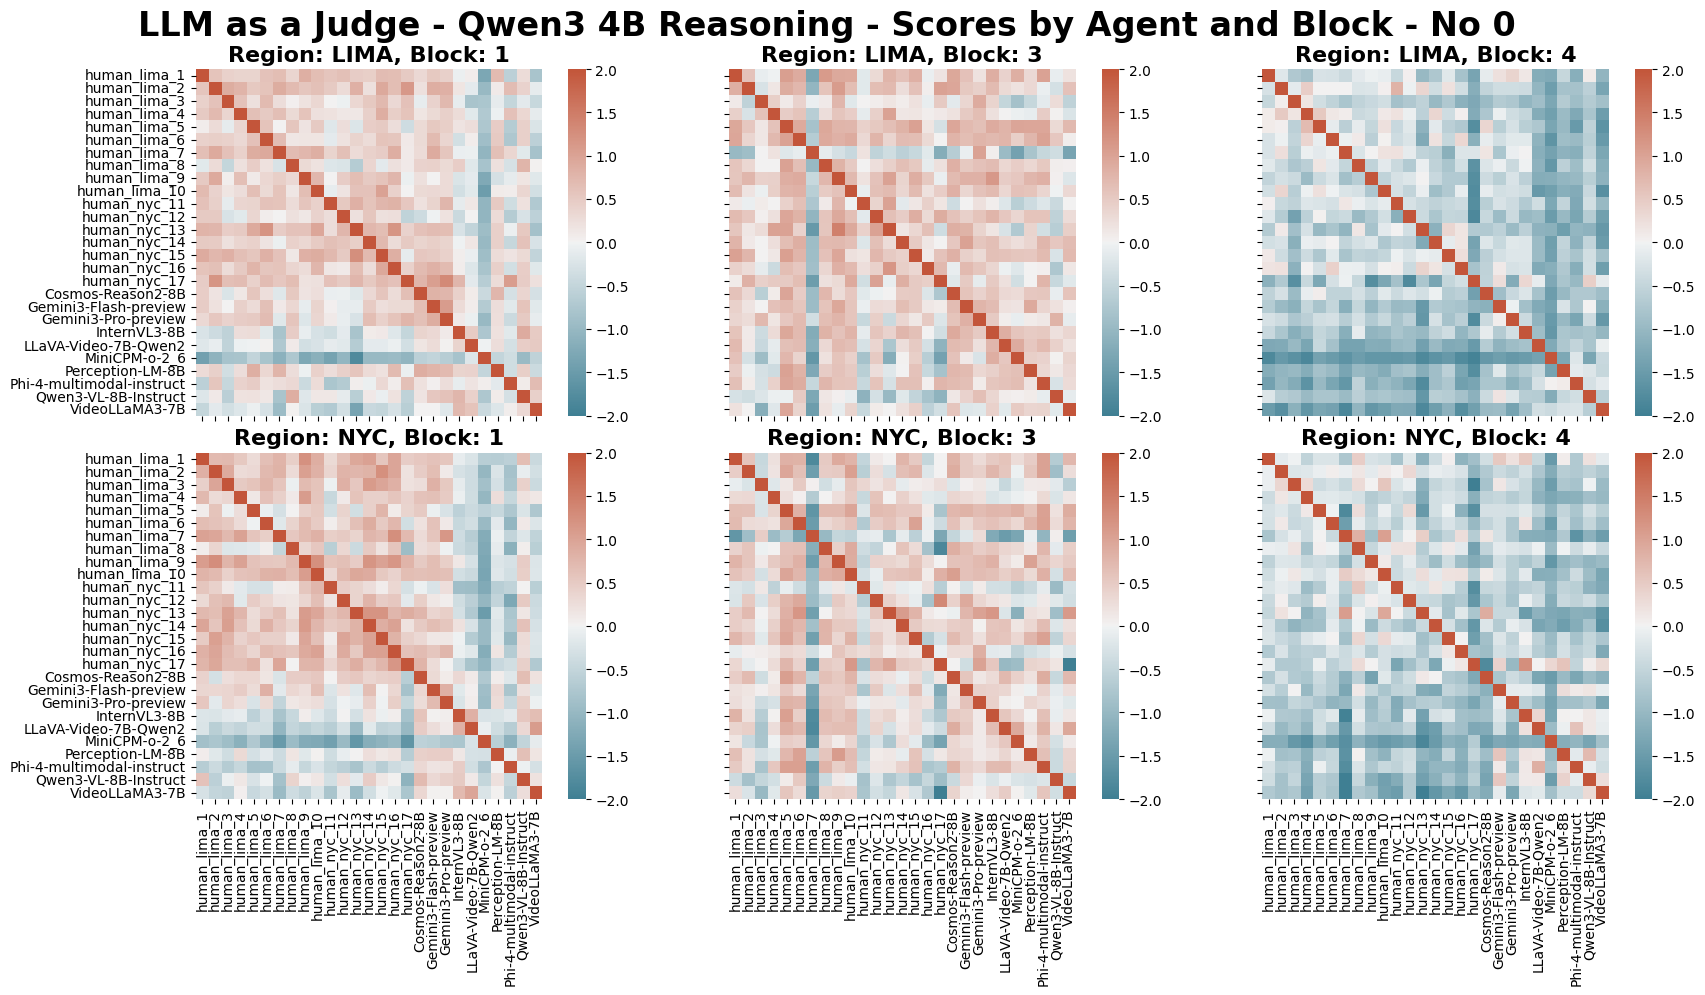

In [ ]:
plot_judge(agg_df2, agents=df_answers["AGENT"].unique(), title="LLM as a Judge - Qwen3 4B Reasoning - Scores by Agent and Block")

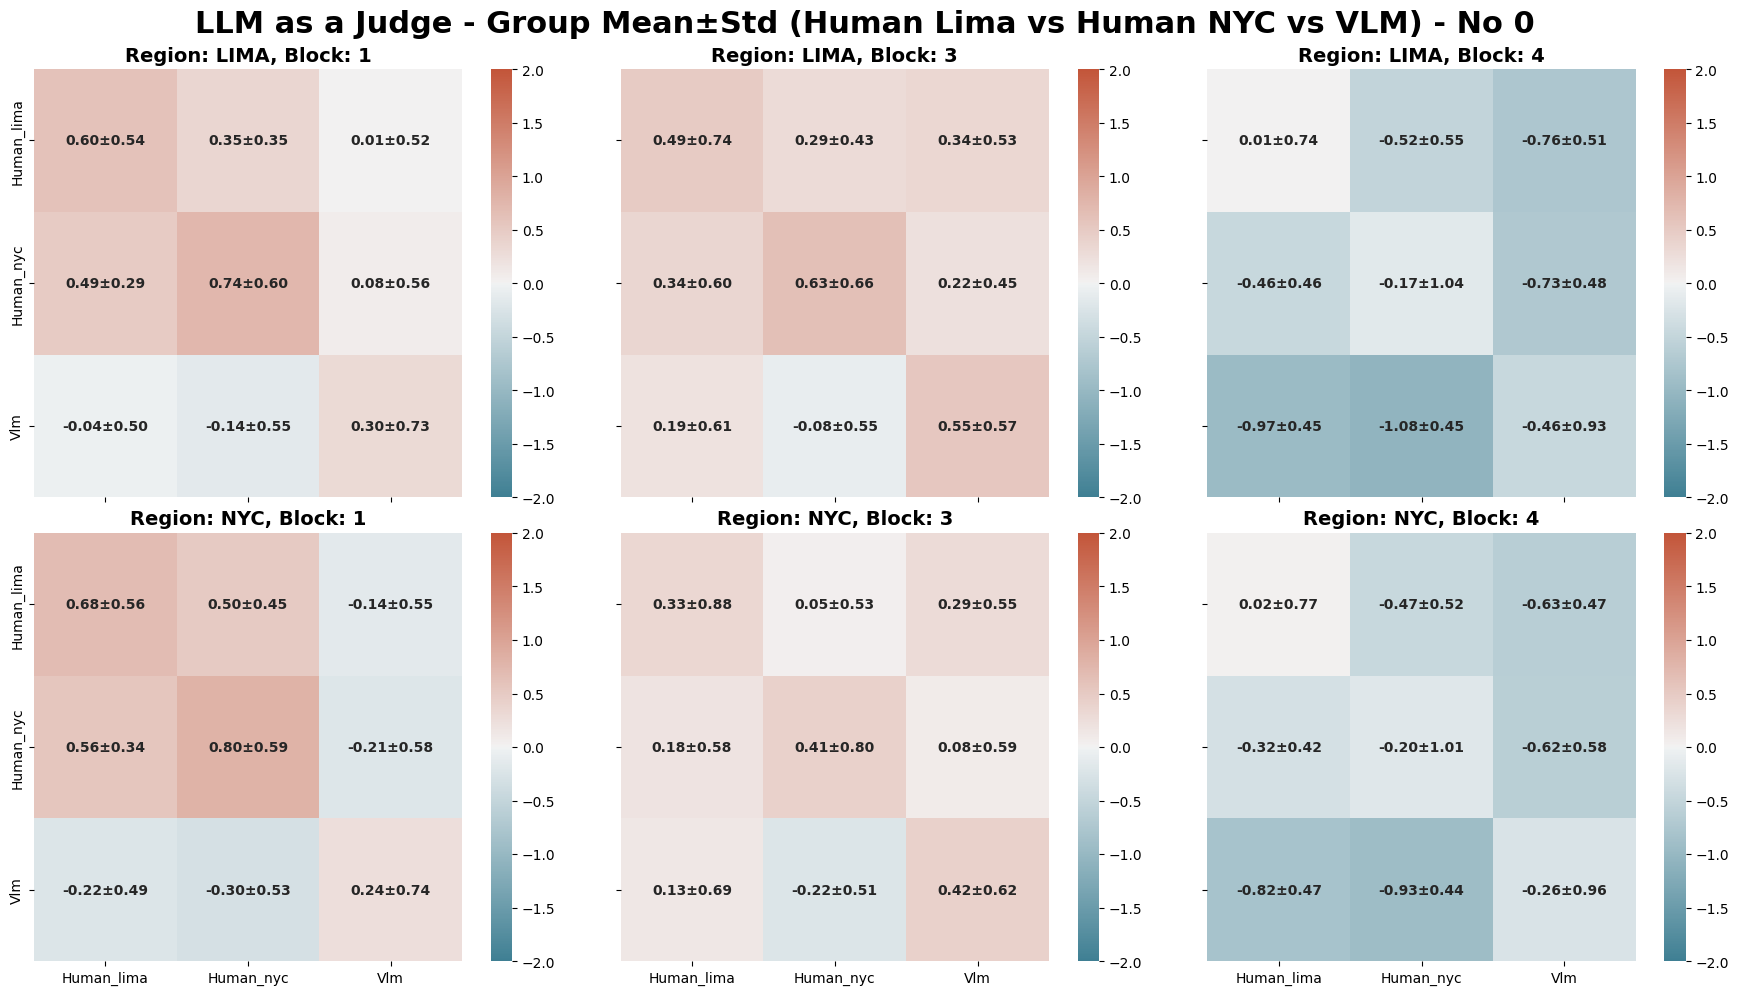

In [ ]:
c = sns.diverging_palette(220, 20, as_cmap=True)

def categorize_agent(agent_name):
    agent_name = str(agent_name).lower()
    if "lima" in agent_name:
        return "Human_lima"
    elif "nyc" in agent_name or "new york" in agent_name:
        return "Human_nyc"
    else:
        return "Vlm"

def build_group_stat_dict(df_scores):
    df = df_scores.copy()
    df["GROUP_I"] = df["AGENT_I"].apply(categorize_agent)
    df["GROUP_J"] = df["AGENT_J"].apply(categorize_agent)

    group_order = ["Human_lima", "Human_nyc", "Vlm"]
    result = {}

    for sector in sorted(df["VIDEO_SECTOR"].unique()):
        for block in sorted(df["BLOCK"].astype(int).unique()):
            df_filtered = df[(df["VIDEO_SECTOR"] == sector) & (df["BLOCK"].astype(int) == int(block))].copy()

            mean_mtx = df_filtered.pivot_table(
                index="GROUP_I", columns="GROUP_J", values="SCORE", aggfunc="mean"
            ).reindex(index=group_order, columns=group_order)

            std_mtx = df_filtered.pivot_table(
                index="GROUP_I", columns="GROUP_J", values="SCORE", aggfunc="std"
            ).reindex(index=group_order, columns=group_order)

            result[(sector, int(block))] = (mean_mtx, std_mtx)

    return result

def plot_group_mean_std_heatmaps(stat_dict, title):
    # sectors = sorted(df_answers["VIDEO_SECTOR"].unique())[::-1]
    sectors = df_answers["VIDEO_SECTOR"].unique()[::-1]
    blocks = sorted(df_answers["BLOCK"].astype(int).unique())
    nrows, ncols = len(sectors), len(blocks)

    fig, ax = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows), sharex=True, sharey=True)
    if nrows == 1 and ncols == 1:
        ax = np.array([[ax]])
    elif nrows == 1:
        ax = np.array([ax])
    elif ncols == 1:
        ax = np.array([[a] for a in ax])

    for i, sector in enumerate(sectors):
        for j, block in enumerate(blocks):
            c_ax = ax[i, j]
            mean_mtx, std_mtx = stat_dict[(sector, int(block))]

            annot_text = []
            for r in range(len(mean_mtx.index)):
                row = []
                for col_idx in range(len(mean_mtx.columns)):
                    m = mean_mtx.iloc[r, col_idx]
                    s = std_mtx.iloc[r, col_idx]
                    if pd.isna(m):
                        row.append("-")
                    elif pd.isna(s):
                        row.append(f"{m:.2f}±0.00")
                    else:
                        row.append(f"{m:.2f}±{s:.2f}")
                annot_text.append(row)

            sns.heatmap(
                mean_mtx.to_numpy(),
                annot=annot_text,
                fmt="",
                cmap=c,
                center=0,
                vmin=-2,
                vmax=2,
                square=True,
                xticklabels=mean_mtx.columns,
                yticklabels=mean_mtx.index,
                annot_kws={"fontsize": 10, "weight": "bold"},
                ax=c_ax,
            )
            c_ax.set_title(f"Region: {sector}, Block: {block}", fontsize=14, weight="bold")

    fig.suptitle(title, fontsize=22, weight="bold")
    fig.tight_layout()
    out_name = title.replace(" ", "_").replace(":", "-").lower()
    fig.subplots_adjust(top=0.92)
    fig.savefig(f"./judge_group_stats_{out_name}.png", dpi=300)

# Build and plot 3x3 group-level mean±std matrices
group_stats = build_group_stat_dict(agg_df2)
plot_group_mean_std_heatmaps(
    group_stats,
    title="LLM as a Judge - Group Mean±Std (Human Lima vs Human NYC vs VLM)",
)

### TEMP

In [ ]:
"""
You are an expert logical analyst.

Task:
Determine if Response A and Response B make claims about the SAME attributes of the SAME objects.

Rules:
- Mark as "COMPARABLE" only if the responses share a "point of contention." (e.g., both mention the color, both mention the motion, or both answer a Yes/No question).
- Mark as "NOT_COMPARABLE" if:
    1. They discuss different attributes of the same object (e.g., A: "The car is red"; B: "The car is a sedan").
    2. They discuss different objects entirely.
    3. One is a factual claim and the other is an "I don't know" or an empty response.

[Few-Shot Examples]
Question: "Is the car moving?"
A: "The car is red." | B: "The car is moving fast." -> NOT_COMPARABLE (different attributes)
A: "The light is green." | B: "The light is red." -> COMPARABLE (same attribute: color)
A: "Yes, it is safe to go." | B: "No, a car is coming." -> COMPARABLE (same conclusion: safety)

Input:
[Question]: {question}
[Response A]: {res_a}
[Response B]: {res_b}

Output ONLY valid JSON:
{{
  "Reasoning": "Briefly explain if they address the same factual point.",
  "Decision": "COMPARABLE" | "NOT_COMPARABLE"
}}
"""